# Assignment 3: Unsupervised Learning + NLP (Bonus)

Fill in the TODO sections and write short theory answers where asked.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage


## Load Dataset

In [ ]:

# TODO: Load the Spotify dataset (or dataset used in Assignment 2)
url = 'https://drive.google.com/uc?export=download&id=1jIiNiySgPaNqBT7HP2CXoUKPjLDaXZwO'
df = pd.read_csv(url)
df.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


## Question 1: Data Preparation

**Q** - Why is feature scaling important in clustering?

**A** - Feature scaling is important because it brings all the features into the same range, which prevents the features with larger ranges from dominating the calculations. This ensures that all the features contribute equally. Therefore, Feature scaling helps in fair clustering.

In [ ]:

features = ["danceability", "energy", "loudness", "tempo", "valence"]

# TODO: Select features
X = df[features]

# TODO: Handle missing values

#To handle the missing values, we will first find the number of missing values in each column
print(df.isnull().sum())

#The rows with missing value
rows_with_missing_value = df[df.isnull().any(axis=1)]
print()
print("Following rows contains missing values" , rows_with_missing_value)

df['track_name'] = df['track_name'].fillna("Track is unknown") #Missingdata (NaN) to be defined as "Track is unknown"
print()
print()
print(df.iloc[54836]) #Now the missing value (track name) to be known as "Track is unknown"

artist_name         0
track_id            0
track_name          1
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
popularity          0
dtype: int64

Following rows contains missing values       artist_name                track_id track_name  acousticness  \
54836  VELVETEARS  2vPmLy7QuLoFfEumm6vAbV        NaN         0.418   

       danceability  duration_ms  energy  instrumentalness  key  liveness  \
54836         0.694       148532   0.407          0.000137    5    0.0785   

       loudness  mode  speechiness   tempo  time_signature  valence  \
54836   -14.235     0       0.0332  90.023               4    0.151   

       popularity  
54836          24  


artist_name                     VELVETEARS
track_id            2vPmLy7QuLoFfEumm6vAbV
track_

In [ ]:

scaler = StandardScaler()
# TODO: Scale features
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()


,danceability,energy,loudness,tempo,valence
0,0.849826,-0.884312,0.350838,2.800232,-1.241440
1,1.391714,-0.046852,0.414862,1.310884,-0.264902
2,0.113279,0.590848,0.624050,-0.149450,-0.222443
3,1.149706,0.037663,-0.327610,0.117033,0.777254
4,1.060268,0.855916,-0.046299,0.019020,1.885026


## Question 2: Hierarchical Clustering

**Q:** What does a dendrogram show?

**A:** A dendrogram shows how data points are grouped together one by one in hierarchical clustering.
It displays which  clusters merge, and at what distance in the dataset. It helping us decide the number of clusters in our dataset.

In [ ]:

# TODO: Perform linkage
df_sample = df.sample(n=5000, random_state=42)

features = ['danceability', 'energy', 'loudness', 'tempo', 'valence']
X = df_sample[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method="ward")


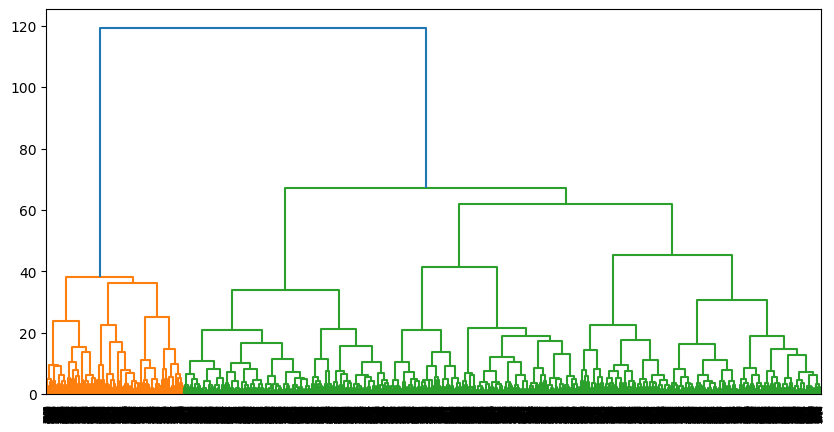

In [ ]:

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.show()


In [ ]:

# TODO: Choose number of clusters
n_clusters = 4
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
df_sample["HC_Cluster"] = hc.fit_predict(X_scaled)
df_sample.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,HC_Cluster
48467,Binaural Beats Sleep,7J4NMfZP1u8KdeJmvTJYVW,Sleep Music (Binaural Beats),0.91600,0.151,193810,0.0266,0.704000,4,0.0946,-31.175,1,0.0463,136.125,4,0.0366,15,3
80470,Arturo de la Torre,2d4BPamRUrIrazuEIMt8ye,Penelope,0.97700,0.534,135347,0.0810,0.898000,0,0.1790,-19.424,0,0.0387,120.311,4,0.0982,2,3
27028,Paperfiends,09U9CoopRQD9PdVWc1XQwn,Road Running Boys,0.00138,0.860,99631,0.4530,0.004200,8,0.1000,-15.657,1,0.1180,129.880,4,0.8110,8,2
7095,The Maine,6GrCoNDjXBp5xun7HRGFuq,The Sound of Reverie (Remix),0.04880,0.551,222143,0.6830,0.000225,1,0.0583,-7.717,1,0.0370,104.987,4,0.3350,30,0
130566,Hasan,3MgCMhIpxo4REZCDc5X1sV,Autumn,0.05610,0.606,128000,0.1030,0.874000,4,0.1030,-11.737,0,0.3320,180.615,4,0.7440,51,0


## Question 3: K-Means Clustering

**Q:** Why does K-Means need K?

**A:** K-Means need k because the algorithm cannot figure out the number of clusters on its own. It does not have any built-in way to decide how many groups exist so without K, There is no reference for “how many clusters to make”


In [ ]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(wcss)

[24999.99999999999]
[24999.99999999999, 17031.161547836517]
[24999.99999999999, 17031.161547836517, 14180.561943818417]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735, 10383.27218185919]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735, 10383.27218185919, 9620.275926283053]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735, 10383.27218185919, 9620.275926283053, 9031.328151530099]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735, 10383.27218185919, 9620.275926283053, 9031.328151530099, 8428.143156076823]
[24999.99999999999, 17031.161547836517, 14180.561943818417, 12360.499435320255, 11176.545120519735, 10383.2721

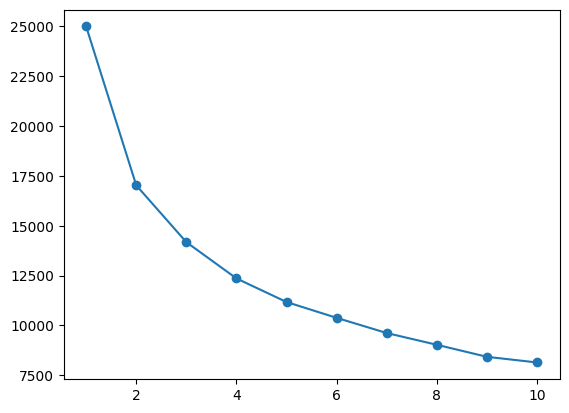

In [ ]:

plt.plot(range(1,11), wcss, marker='o')
plt.show()


In [ ]:

# TODO: Choose optimal K
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_sample["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
df_sample.head()


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,HC_Cluster,KMeans_Cluster
48467,Binaural Beats Sleep,7J4NMfZP1u8KdeJmvTJYVW,Sleep Music (Binaural Beats),0.91600,0.151,193810,0.0266,0.704000,4,0.0946,-31.175,1,0.0463,136.125,4,0.0366,15,3,0
80470,Arturo de la Torre,2d4BPamRUrIrazuEIMt8ye,Penelope,0.97700,0.534,135347,0.0810,0.898000,0,0.1790,-19.424,0,0.0387,120.311,4,0.0982,2,3,0
27028,Paperfiends,09U9CoopRQD9PdVWc1XQwn,Road Running Boys,0.00138,0.860,99631,0.4530,0.004200,8,0.1000,-15.657,1,0.1180,129.880,4,0.8110,8,2,1
7095,The Maine,6GrCoNDjXBp5xun7HRGFuq,The Sound of Reverie (Remix),0.04880,0.551,222143,0.6830,0.000225,1,0.0583,-7.717,1,0.0370,104.987,4,0.3350,30,0,2
130566,Hasan,3MgCMhIpxo4REZCDc5X1sV,Autumn,0.05610,0.606,128000,0.1030,0.874000,4,0.1030,-11.737,0,0.3320,180.615,4,0.7440,51,0,1


## Question 4: PCA Visualization

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=["PC1","PC2"])
X_pca.head()


,PC1,PC2
0,-4.369744,0.970536
1,-2.407868,-0.041806
2,0.575521,-1.564045
3,0.105084,0.207542
4,-0.087370,-0.051248


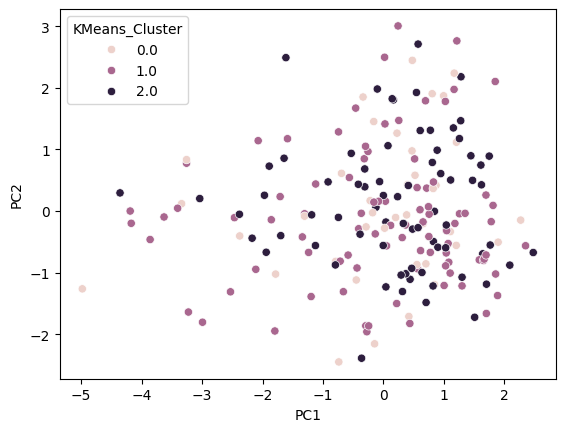

In [ ]:

sns.scatterplot(x=X_pca.PC1, y=X_pca.PC2, hue=df_sample["KMeans_Cluster"])
plt.show()


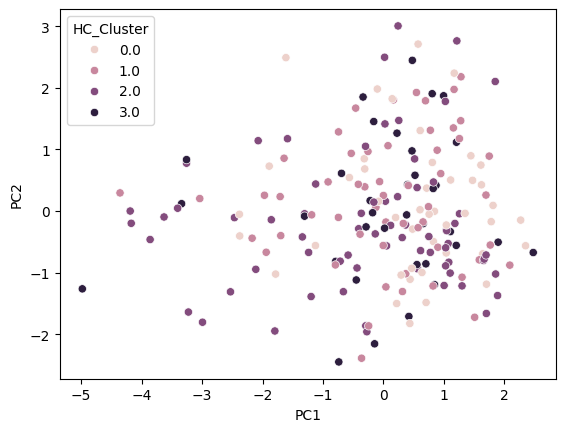

In [ ]:

sns.scatterplot(x=X_pca.PC1, y=X_pca.PC2, hue=df_sample["HC_Cluster"])
plt.show()


## Question 5: Gaussian Mixture Models

**Q:** Difference between K-Means and GMM?

**A:** K-Means groups data based on distance to the nearest center while GMM groups data based on probability. In K-Means, Each data point belongs to only one cluster but in GMM Each data point has a probability of belonging to each cluster. K-Means assumes clusters are round and similar in size while GMM can model overlapping and uneven-shaped clusters. K-Means is simpler and faster while GMM is moreflaxible but a bit slower.




In [ ]:

# TODO: Initialize and fit GMM
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df_sample["GMM_Cluster"] = gmm.fit_predict(X_scaled)
df_sample.head()


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,HC_Cluster,KMeans_Cluster,GMM_Cluster
48467,Binaural Beats Sleep,7J4NMfZP1u8KdeJmvTJYVW,Sleep Music (Binaural Beats),0.91600,0.151,193810,0.0266,0.704000,4,0.0946,-31.175,1,0.0463,136.125,4,0.0366,15,3,0,0
80470,Arturo de la Torre,2d4BPamRUrIrazuEIMt8ye,Penelope,0.97700,0.534,135347,0.0810,0.898000,0,0.1790,-19.424,0,0.0387,120.311,4,0.0982,2,3,0,0
27028,Paperfiends,09U9CoopRQD9PdVWc1XQwn,Road Running Boys,0.00138,0.860,99631,0.4530,0.004200,8,0.1000,-15.657,1,0.1180,129.880,4,0.8110,8,2,1,0
7095,The Maine,6GrCoNDjXBp5xun7HRGFuq,The Sound of Reverie (Remix),0.04880,0.551,222143,0.6830,0.000225,1,0.0583,-7.717,1,0.0370,104.987,4,0.3350,30,0,2,2
130566,Hasan,3MgCMhIpxo4REZCDc5X1sV,Autumn,0.05610,0.606,128000,0.1030,0.874000,4,0.1030,-11.737,0,0.3320,180.615,4,0.7440,51,0,1,0


In [ ]:

# TODO: Show soft cluster probabilities
gmm_probs = gmm.predict_proba(X_scaled)
gmm_probs[:5]

array([[1.00000000e+00, 3.39143875e-23, 3.99669356e-19],
       [9.95879169e-01, 1.39906634e-05, 4.10683986e-03],
       [5.84799027e-01, 4.15128827e-01, 7.21460638e-05],
       [1.68900431e-02, 2.33831331e-01, 7.49278626e-01],
       [9.54800605e-01, 9.50628925e-04, 4.42487660e-02]])

## BONUS: NLP

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

text = "Machine learning enables systems to learn from data."
# TODO: Tokenization, stemming, lemmatization

# Tokenization
tokens = word_tokenize(text)
print("Tokens:", tokens)

#Stemming
stemmer = PorterStemmer()
stems = [stemmer.stem(word) for word in tokens]
print("Stems:", stems)

# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(word) for word in tokens]
print("Lemmas:", lemmas)

Tokens: ['Machine', 'learning', 'enables', 'systems', 'to', 'learn', 'from', 'data', '.']
Stems: ['machin', 'learn', 'enabl', 'system', 'to', 'learn', 'from', 'data', '.']
Lemmas: ['Machine', 'learning', 'enables', 'system', 'to', 'learn', 'from', 'data', '.']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

sentences = [
    "Machine learning is powerful",
    "Unsupervised learning finds patterns",
    "Clustering groups similar data"
]

# TODO: Apply Bag of Words or TF-IDF
